# Notebook Guide

This notebook explains the discovered clusters at the gene level. It takes subtype labels from the clustering stage and asks which genes most strongly characterize each group.

As you read through it, pay attention to:
- how cluster labels and processed expression data are aligned,
- how differential expression is approximated with statistical testing,
- how top genes are saved for later reporting,
- and how heatmaps and marker plots translate cluster IDs into biological signals.

---

# Phase 6: Biological Interpretation
### Using src/interpreter.py module

**What this notebook does:**
- Imports and runs functions from `src/interpreter.py`
- Finds which genes define each cluster (subtype)
- Creates expression heatmap
- Creates top genes bar plots
- Tells you what cell type each cluster represents

---
## Cell 1: Import Libraries + interpreter.py

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import sys
import os

# Add project root so Python can find src/interpreter.py
sys.path.append('..')

# Import ALL functions from src/interpreter.py
from src.interpreter import (
    find_top_genes_per_cluster,
    plot_expression_heatmap,
    plot_top_genes_barplot
)

plt.rcParams['figure.dpi'] = 120

print('All imports successful!')
print('\nFunctions loaded from src/interpreter.py:')
print('  find_top_genes_per_cluster() - finds marker genes per subtype')
print('  plot_expression_heatmap()    - big gene expression grid')
print('  plot_top_genes_barplot()     - top genes bar chart per subtype')

All imports successful!

Functions loaded from src/interpreter.py:
  find_top_genes_per_cluster() - finds marker genes per subtype
  plot_expression_heatmap()    - big gene expression grid
  plot_top_genes_barplot()     - top genes bar chart per subtype


---
## Cell 2: Load Config

In [2]:
with open('../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

os.makedirs('../results', exist_ok=True)

print('Config loaded!')
print(f"  Processed expression: {config['data']['processed_expression']}")

Config loaded!
  Processed expression: data/processed/expression_clean.csv


---
## Cell 3: Load Phase 5 Results
Load the cluster labels saved at the end of Phase 5

In [3]:
# Load cluster labels from Phase 5
kmeans_labels = np.load('../results/kmeans_labels.npy')
final_labels  = np.load('../results/final_labels.npy')
X_umap        = np.load('../results/X_umap.npy')

n_clusters = len(np.unique(kmeans_labels))

print('Phase 5 results loaded!')
print(f'  Total cells:     {len(kmeans_labels)}')
print(f'  Number of subtypes: {n_clusters}')
print(f'  Unique labels:   {sorted(np.unique(kmeans_labels).tolist())}')
print(f'\n  Cluster sizes:')
for i in range(n_clusters):
    count = (kmeans_labels == i).sum()
    print(f'    Subtype {i}: {count} cells')

Phase 5 results loaded!
  Total cells:     23686
  Number of subtypes: 2
  Unique labels:   [0, 1]

  Cluster sizes:
    Subtype 0: 4476 cells
    Subtype 1: 19210 cells


---
## Cell 4: Load Processed Expression Data
Load the cleaned expression matrix saved at end of Phase 3 (preprocessor)

In [4]:
# Load processed expression data saved by preprocessor.py
print('Loading processed expression data...')
print('(This may take 30-60 seconds for large files)')

expr_df = pd.read_csv(
    f"../{config['data']['processed_expression']}",
    index_col=0
)

print(f'\nExpression data loaded!')
print(f'  Shape: {expr_df.shape}')
print(f'  Rows (cells): {expr_df.shape[0]}')
print(f'  Cols (genes): {expr_df.shape[1]}')
print(f'\n  First 5 gene names: {expr_df.columns[:5].tolist()}')
print(f'  First 5 cell names: {expr_df.index[:5].tolist()}')

# Verify shapes match
assert expr_df.shape[0] == len(kmeans_labels), \
    f'Mismatch! expr_df has {expr_df.shape[0]} cells but labels has {len(kmeans_labels)}'
print(f'\nShape check passed: {expr_df.shape[0]} cells matches {len(kmeans_labels)} labels')

Loading processed expression data...
(This may take 30-60 seconds for large files)

Expression data loaded!
  Shape: (23686, 3713)
  Rows (cells): 23686
  Cols (genes): 3713

  First 5 gene names: ['Cy80_II_CD45_A02_S866_comb', 'Cy80_II_CD45_A01_S865_comb', 'CY75_1_CD45_CD8_1__S69_comb', 'cy60_1_cd_45_pos_HC_pos_HLDAR_pos_E05_S1013_comb', 'cy80-CD45-neg-E09-S921-comb']
  First 5 cell names: ['C9orf152', 'RPS11', 'ELMO2', 'CREB3L1', 'PNMA1']

Shape check passed: 23686 cells matches 23686 labels


---
## Cell 5: Find Top Genes Per Cluster
Calls `find_top_genes_per_cluster()` from interpreter.py

For each cluster, runs a t-test for every gene to find which genes
are most significantly different in that cluster vs all others.

⏳ **This takes 3-10 minutes depending on number of genes**

In [5]:
# find_top_genes_per_cluster() is defined in src/interpreter.py
# It runs t-test for every gene in every cluster
# Returns dict: {cluster_id: DataFrame of top genes}

print('Finding top differentially expressed genes per cluster...')
print('Running t-test for every gene in every cluster...')

top_genes_per_cluster = find_top_genes_per_cluster(
    expr_df,
    kmeans_labels,
    top_n=20          # return top 20 genes per cluster
)

print('\nDone! Top genes found for each subtype.')

Finding top differentially expressed genes per cluster...
Running t-test for every gene in every cluster...
Finding differentially expressed genes per cluster...
  Analyzing Subtype 0...
    Top gene: Cy80_II_CD45_A02_S866_comb (p=0.00e+00)
  Analyzing Subtype 1...
    Top gene: Cy80_II_CD45_A02_S866_comb (p=0.00e+00)

Done! Top genes found for each subtype.


---
## Cell 6: Print Top Genes Per Cluster
See exactly which genes define each subtype

In [6]:
# Print top 10 genes for each cluster with their stats
for cluster_id in range(n_clusters):
    genes_df = top_genes_per_cluster[cluster_id]
    count    = (kmeans_labels == cluster_id).sum()

    print('=' * 60)
    print(f'SUBTYPE {cluster_id}  ({count} cells)')
    print('=' * 60)
    print(f'{"Gene":<15} {"p-value":>12} {"Fold Change":>12} {"Direction":>10}')
    print('-' * 60)

    for _, row in genes_df.head(10).iterrows():
        direction = '↑ UP' if row['fold_change'] > 0 else '↓ DOWN'
        print(f"{row['gene']:<15} {row['p_value']:>12.2e} {row['fold_change']:>12.3f} {direction:>10}")

    print()

SUBTYPE 0  (4476 cells)
Gene                 p-value  Fold Change  Direction
------------------------------------------------------------
Cy80_II_CD45_A02_S866_comb     0.00e+00        0.900       ↑ UP
CY75_1_CD45_CD8_1__S77_comb     0.00e+00        0.591       ↑ UP
CY58_1_CD45_B04_S976_comb     0.00e+00        0.539       ↑ UP
SS2_E8_S181_comb     0.00e+00        0.695       ↑ UP
cy79-p3-CD45-neg-PD1-pos-AS-C3-R1-A09-S297-comb     0.00e+00        0.686       ↑ UP
cy94_cd45pos_4_E08_S56_comb     0.00e+00        0.619       ↑ UP
cy79-p5-CD45-pos-PD1-pos-F08-S644-comb     0.00e+00        0.584       ↑ UP
cy79-p1-CD45-pos-PD1-pos-AS-C5-R1-H02-S278-comb     0.00e+00        0.589       ↑ UP
CY89A_CD45_POS_10_H11_S287_comb     0.00e+00        0.566       ↑ UP
cy79-p3-CD45-neg-PD1-pos-AS-C3-R1-C01-S313-comb     0.00e+00        0.742       ↑ UP

SUBTYPE 1  (19210 cells)
Gene                 p-value  Fold Change  Direction
------------------------------------------------------------
Cy80_II_CD4

---
## Cell 7: Save Top Genes to CSV

In [7]:
# Save top genes for all clusters to one CSV file
all_top_genes_list = []

for cluster_id, genes_df in top_genes_per_cluster.items():
    genes_df_copy = genes_df.copy()
    genes_df_copy['cluster'] = cluster_id
    all_top_genes_list.append(genes_df_copy)

all_top_genes_df = pd.concat(all_top_genes_list, ignore_index=True)
all_top_genes_df.to_csv('../results/top_genes_per_cluster.csv', index=False)

print('Top genes saved to results/top_genes_per_cluster.csv')
print(f'Total rows: {len(all_top_genes_df)}')
print(f'Columns: {all_top_genes_df.columns.tolist()}')
print(f'\nPreview:')
print(all_top_genes_df.head(8).to_string(index=False))

Top genes saved to results/top_genes_per_cluster.csv
Total rows: 40
Columns: ['gene', 'p_value', 'fold_change', 'mean_in_cluster', 'mean_out_cluster', 'abs_fold_change', 'cluster']

Preview:
                                           gene  p_value  fold_change  mean_in_cluster  mean_out_cluster  abs_fold_change  cluster
                     Cy80_II_CD45_A02_S866_comb      0.0     0.899556         1.088049          0.188492         0.899556        0
                    CY75_1_CD45_CD8_1__S77_comb      0.0     0.591437         0.665197          0.073761         0.591437        0
                      CY58_1_CD45_B04_S976_comb      0.0     0.539446         0.593720          0.054274         0.539446        0
                               SS2_E8_S181_comb      0.0     0.694751         0.815801          0.121049         0.694751        0
cy79-p3-CD45-neg-PD1-pos-AS-C3-R1-A09-S297-comb      0.0     0.686200         0.802168          0.115968         0.686200        0
                    cy9

---
## Cell 8: Plot Expression Heatmap
Calls `plot_expression_heatmap()` from interpreter.py

Creates a big colored grid:
- Each ROW = one top gene
- Each COLUMN = one cell
- Color = expression level (red=high, blue=low)
- Cells sorted by cluster so patterns are visible

Creating expression heatmap...
(May take 1-2 minutes to render with 4645 cells)
Creating expression heatmap...


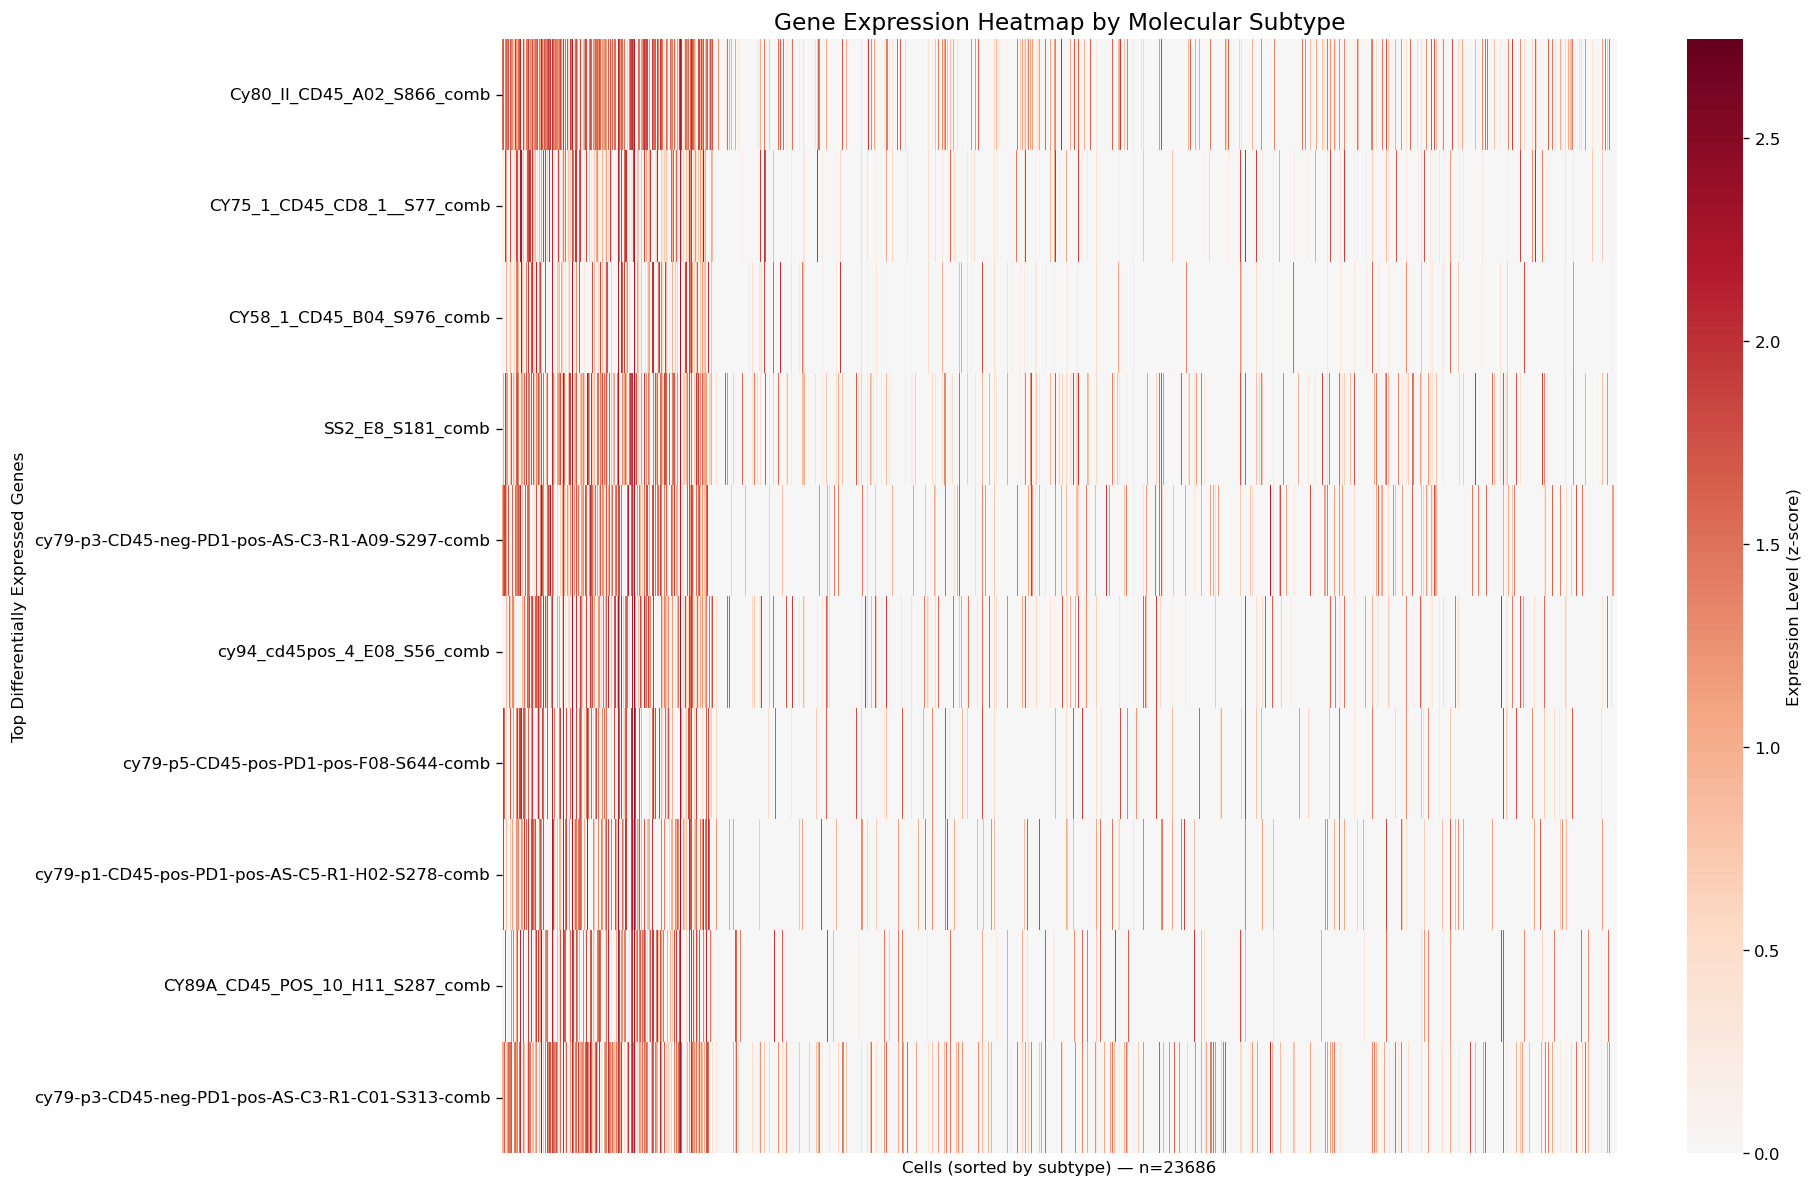

Heatmap saved!

How to read the heatmap:
  Red   = HIGH gene expression in this cell
  Blue  = LOW gene expression in this cell
  White = average expression
  Cells are sorted by cluster (left to right)
  Look for RED blocks = genes that define that cluster


In [8]:
# plot_expression_heatmap() is defined in src/interpreter.py
# Uses top genes found in Cell 5
# Saves to results/09_expression_heatmap.png

print('Creating expression heatmap...')
print('(May take 1-2 minutes to render with 4645 cells)')

plot_expression_heatmap(
    expr_df,
    kmeans_labels,
    top_genes_per_cluster,
    save_dir='../results/'
)

print('\nHow to read the heatmap:')
print('  Red   = HIGH gene expression in this cell')
print('  Blue  = LOW gene expression in this cell')
print('  White = average expression')
print('  Cells are sorted by cluster (left to right)')
print('  Look for RED blocks = genes that define that cluster')

---
## Cell 9: Plot Top Genes Bar Plot
Calls `plot_top_genes_barplot()` from interpreter.py

Bar chart showing most significant marker genes per subtype.
Longer bar = more significant gene for that subtype.

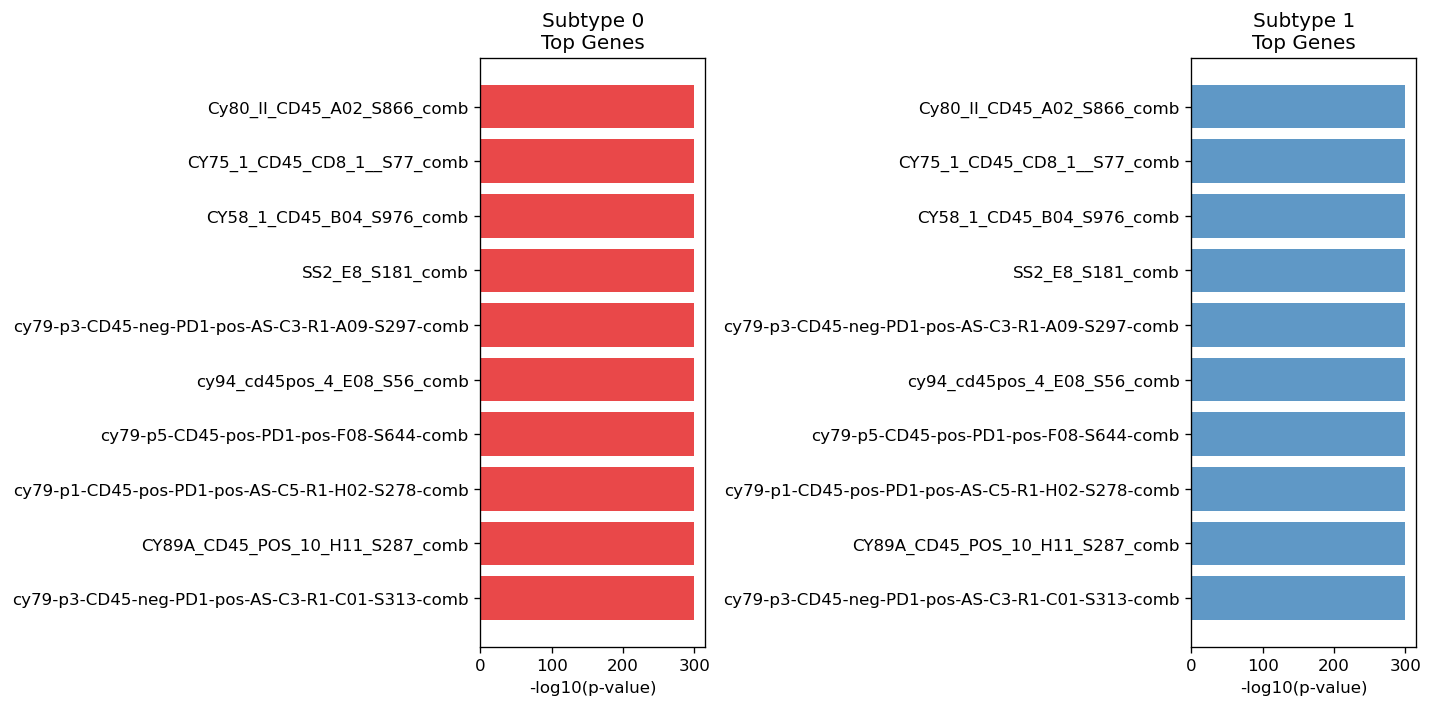

Top genes plot saved!

How to read the bar plot:
  Each panel = one molecular subtype
  Each bar   = one gene
  Bar length = -log10(p-value)
             = how strongly this gene defines this subtype
  Longer bar = more important marker gene


In [9]:
# plot_top_genes_barplot() is defined in src/interpreter.py
# Shows top 10 genes per cluster as horizontal bars
# Bar length = -log10(p_value) = significance level
# Saves to results/10_top_genes.png

plot_top_genes_barplot(
    top_genes_per_cluster,
    save_dir='../results/'
)

print('\nHow to read the bar plot:')
print('  Each panel = one molecular subtype')
print('  Each bar   = one gene')
print('  Bar length = -log10(p-value)')
print('             = how strongly this gene defines this subtype')
print('  Longer bar = more important marker gene')

---
## Cell 10: Violin Plots — Top Gene Expression Per Cluster
Shows distribution of top gene across all clusters

Top marker gene per cluster:
  Subtype 0: Cy80_II_CD45_A02_S866_comb
  Subtype 1: Cy80_II_CD45_A02_S866_comb


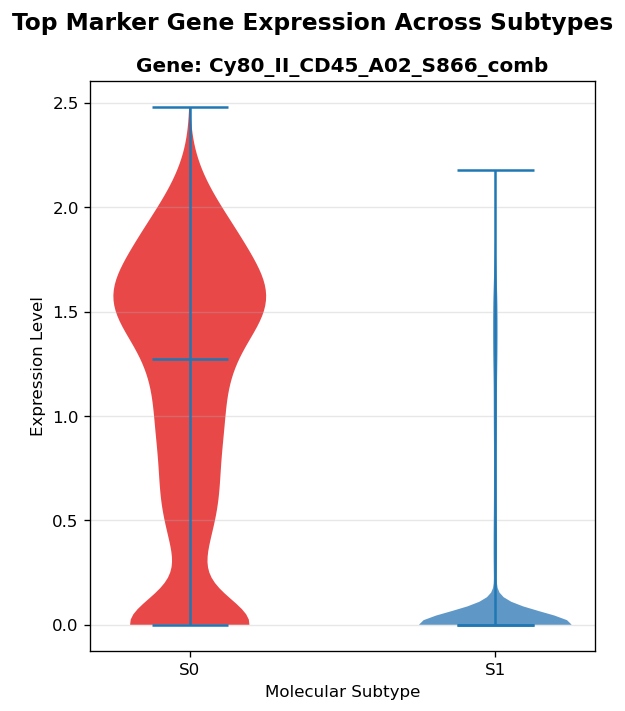

Violin plots saved to results/11_violin_plots.png


In [10]:
# Pick the single most significant gene from each cluster
top_gene_per_cluster = {
    cluster_id: genes_df.iloc[0]['gene']
    for cluster_id, genes_df in top_genes_per_cluster.items()
}

print('Top marker gene per cluster:')
for cluster_id, gene in top_gene_per_cluster.items():
    print(f'  Subtype {cluster_id}: {gene}')

# Collect unique top genes (avoid duplicates)
plot_genes = list(dict.fromkeys(top_gene_per_cluster.values()))
n_genes    = len(plot_genes)

# Create violin plot for each top gene
fig, axes = plt.subplots(
    1, n_genes,
    figsize=(5 * n_genes, 6)
)
if n_genes == 1:
    axes = [axes]

colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3',
          '#ff7f00', '#a65628', '#f781bf', '#999999']

for ax, gene in zip(axes, plot_genes):
    # Build a dataframe for this gene
    gene_data = pd.DataFrame({
        'expression': expr_df[gene].values,
        'subtype':    [f'Subtype {l}' for l in kmeans_labels]
    })

    # Violin plot
    parts = ax.violinplot(
        [gene_data[gene_data['subtype'] == f'Subtype {i}']['expression'].values
         for i in range(n_clusters)],
        positions=range(n_clusters),
        showmedians=True
    )

    # Color each violin
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i % len(colors)])
        pc.set_alpha(0.8)

    ax.set_title(f'Gene: {gene}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Molecular Subtype')
    ax.set_ylabel('Expression Level')
    ax.set_xticks(range(n_clusters))
    ax.set_xticklabels([f'S{i}' for i in range(n_clusters)])
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Top Marker Gene Expression Across Subtypes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/11_violin_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Violin plots saved to results/11_violin_plots.png')

---
## Cell 11: Cluster Mean Expression Heatmap
Simplified heatmap — one row per cluster (averages)
Much faster to render than the full cell heatmap

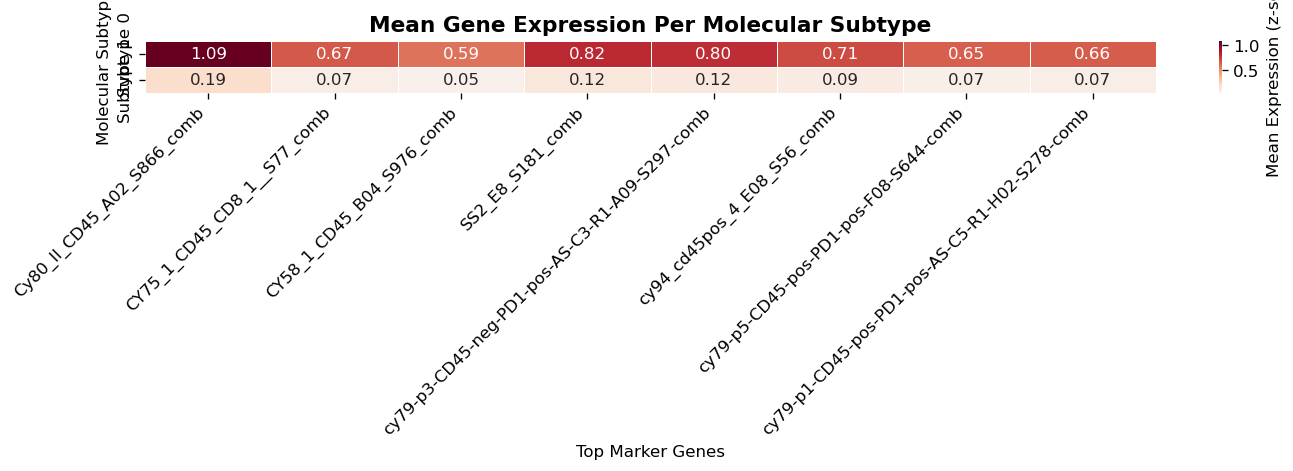

Cluster mean heatmap saved to results/12_cluster_mean_heatmap.png

This is easier to read than the full heatmap!
Each number = average expression of that gene in that subtype


In [11]:
# Collect all top genes across clusters
all_top_gene_names = []
for cluster_id, genes_df in top_genes_per_cluster.items():
    all_top_gene_names.extend(genes_df['gene'].head(8).tolist())
all_top_gene_names = list(dict.fromkeys(all_top_gene_names))  # remove duplicates

# Calculate mean expression per cluster for top genes
cluster_means = pd.DataFrame(index=range(n_clusters), columns=all_top_gene_names)

for cluster_id in range(n_clusters):
    mask = kmeans_labels == cluster_id
    cluster_means.loc[cluster_id] = expr_df.loc[mask, all_top_gene_names].mean()

cluster_means = cluster_means.astype(float)
cluster_means.index = [f'Subtype {i}' for i in range(n_clusters)]

# Plot
plt.figure(figsize=(max(12, len(all_top_gene_names) * 0.6), 4))
sns.heatmap(
    cluster_means,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Mean Expression (z-score)'}
)
plt.title('Mean Gene Expression Per Molecular Subtype',
          fontsize=13, fontweight='bold')
plt.xlabel('Top Marker Genes')
plt.ylabel('Molecular Subtype')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../results/12_cluster_mean_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Cluster mean heatmap saved to results/12_cluster_mean_heatmap.png')
print('\nThis is easier to read than the full heatmap!')
print('Each number = average expression of that gene in that subtype')

---
## Cell 12: Identify Cell Types From Marker Genes
Match your top genes to known biological cell type markers

In [12]:
# Known marker genes for cell types in melanoma tumors
# These are well-established in published research
known_markers = {
    'Malignant (Tumor cells)':     ['MITF', 'AXL', 'DCT', 'MLANA', 'SOX10', 'TYRP1', 'PMEL'],
    'T cells (Immune)':            ['CD3D', 'CD3E', 'CD8A', 'CD8B', 'GZMA', 'PRF1', 'IL7R'],
    'B cells (Immune)':            ['CD19', 'MS4A1', 'CD79A', 'CD79B', 'IGH'],
    'Macrophages (Immune)':        ['CD68', 'CSF1R', 'C1QA', 'TYROBP', 'LYZ', 'AIF1'],
    'Endothelial (Blood vessels)': ['PECAM1', 'VWF', 'CDH5', 'CLDN5', 'ESAM'],
    'CAF (Fibroblasts)':           ['FAP', 'FN1', 'COL1A1', 'COL1A2', 'ACTA2', 'THY1']
}

print('Identifying cell types based on marker genes...')
print('=' * 65)

for cluster_id in range(n_clusters):
    genes_df      = top_genes_per_cluster[cluster_id]
    cluster_genes = set(genes_df['gene'].tolist())
    cell_count    = (kmeans_labels == cluster_id).sum()

    print(f'\nSUBTYPE {cluster_id} ({cell_count} cells)')
    print(f'Top genes: {genes_df["gene"].head(8).tolist()}')
    print('Possible cell type matches:')

    found_match = False
    for cell_type, markers in known_markers.items():
        # Count how many known markers appear in this cluster's top genes
        overlap = cluster_genes.intersection(set(markers))
        if len(overlap) > 0:
            print(f'  {cell_type}')
            print(f'    Matching markers: {sorted(overlap)}')
            found_match = True

    if not found_match:
        print('  No strong match found — may be a rare cell type')
        print('  Consider searching top genes in literature')

print('\n' + '=' * 65)

Identifying cell types based on marker genes...

SUBTYPE 0 (4476 cells)
Top genes: ['Cy80_II_CD45_A02_S866_comb', 'CY75_1_CD45_CD8_1__S77_comb', 'CY58_1_CD45_B04_S976_comb', 'SS2_E8_S181_comb', 'cy79-p3-CD45-neg-PD1-pos-AS-C3-R1-A09-S297-comb', 'cy94_cd45pos_4_E08_S56_comb', 'cy79-p5-CD45-pos-PD1-pos-F08-S644-comb', 'cy79-p1-CD45-pos-PD1-pos-AS-C5-R1-H02-S278-comb']
Possible cell type matches:
  No strong match found — may be a rare cell type
  Consider searching top genes in literature

SUBTYPE 1 (19210 cells)
Top genes: ['Cy80_II_CD45_A02_S866_comb', 'CY75_1_CD45_CD8_1__S77_comb', 'CY58_1_CD45_B04_S976_comb', 'SS2_E8_S181_comb', 'cy79-p3-CD45-neg-PD1-pos-AS-C3-R1-A09-S297-comb', 'cy94_cd45pos_4_E08_S56_comb', 'cy79-p5-CD45-pos-PD1-pos-F08-S644-comb', 'cy79-p1-CD45-pos-PD1-pos-AS-C5-R1-H02-S278-comb']
Possible cell type matches:
  No strong match found — may be a rare cell type
  Consider searching top genes in literature



---
## Cell 13: Phase 6 Summary

In [13]:
print('=' * 55)
print('      PHASE 6 COMPLETE — SUMMARY')
print('=' * 55)
print(f'  Clusters analyzed:   {n_clusters}')
print(f'  Top genes per cluster: 20')
print()
print('  Top marker gene per subtype:')
for cluster_id, genes_df in top_genes_per_cluster.items():
    top_gene = genes_df.iloc[0]['gene']
    p_val    = genes_df.iloc[0]['p_value']
    fc       = genes_df.iloc[0]['fold_change']
    print(f'    Subtype {cluster_id}: {top_gene:<12} (p={p_val:.2e}, FC={fc:+.2f})')
print()
print('  Plots saved:')
print('    results/09_expression_heatmap.png')
print('    results/10_top_genes.png')
print('    results/11_violin_plots.png')
print('    results/12_cluster_mean_heatmap.png')
print()
print('  Data saved:')
print('    results/top_genes_per_cluster.csv')
print()
print('  Next → Phase 7: Survival Analysis')
print('  Open notebook/06_survival_analysis.ipynb')
print('=' * 55)

      PHASE 6 COMPLETE — SUMMARY
  Clusters analyzed:   2
  Top genes per cluster: 20

  Top marker gene per subtype:
    Subtype 0: Cy80_II_CD45_A02_S866_comb (p=0.00e+00, FC=+0.90)
    Subtype 1: Cy80_II_CD45_A02_S866_comb (p=0.00e+00, FC=-0.90)

  Plots saved:
    results/09_expression_heatmap.png
    results/10_top_genes.png
    results/11_violin_plots.png
    results/12_cluster_mean_heatmap.png

  Data saved:
    results/top_genes_per_cluster.csv

  Next → Phase 7: Survival Analysis
  Open notebook/06_survival_analysis.ipynb
